## 🏏 IPL Data Analysis (2008-2025)
**Tools:** Python, Pandas, Matplotlib, SQL  
**Goal:** Analyze IPL player and team performance




In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
ipl=pd.read_csv("IPL.csv",low_memory=False)
ipl.head()

,Unnamed: 0,match_id,date,match_type,event_name,innings,batting_team,bowling_team,over,ball,...,team_balls,team_wicket,new_batter,power_surge_start,batter_runs,batter_balls,bowler_wicket,batting_partners,next_batter,striker_out
0,141607,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,...,1,0,NaN,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
1,141608,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,...,2,0,NaN,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
2,141609,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,...,2,0,NaN,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
3,141610,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,...,3,0,NaN,NaN,0,2,0,"('BB McCullum', 'SC Ganguly')",NaN,False
4,141611,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,...,4,0,NaN,NaN,0,3,0,"('BB McCullum', 'SC Ganguly')",NaN,False


In [3]:
print(ipl.columns.tolist())


['Unnamed: 0', 'match_id', 'date', 'match_type', 'event_name', 'innings', 'batting_team', 'bowling_team', 'over', 'ball', 'ball_no', 'batter', 'bat_pos', 'runs_batter', 'balls_faced', 'bowler', 'valid_ball', 'runs_extras', 'runs_total', 'runs_bowler', 'runs_not_boundary', 'extra_type', 'non_striker', 'non_striker_pos', 'wicket_kind', 'player_out', 'fielders', 'runs_target', 'review_batter', 'team_reviewed', 'review_decision', 'umpire', 'umpires_call', 'player_of_match', 'match_won_by', 'win_outcome', 'toss_winner', 'toss_decision', 'venue', 'city', 'day', 'month', 'year', 'season', 'gender', 'team_type', 'superover_winner', 'result_type', 'method', 'balls_per_over', 'overs', 'event_match_no', 'stage', 'match_number', 'team_runs', 'team_balls', 'team_wicket', 'new_batter', 'power_surge_start', 'batter_runs', 'batter_balls', 'bowler_wicket', 'batting_partners', 'next_batter', 'striker_out']


In [4]:
print(ipl.isnull().sum())

Unnamed: 0               0
match_id                 0
date                     0
match_type               0
event_name               0
                     ...  
batter_balls             0
bowler_wicket            0
batting_partners         0
next_batter         270085
striker_out              0
Length: 65, dtype: int64


In [5]:
# Extract year from date
ipl['year'] = pd.to_datetime(ipl['date']).dt.year

# Check last ball of each match (final result)
# Group by match_id and get last row
last_ball = ipl.groupby('match_id').last().reset_index()

# See what we get
print(last_ball[['match_id', 'year', 'batting_team', 'bowling_team']].head(100))

    match_id  year                 batting_team           bowling_team
0     335982  2008  Royal Challengers Bangalore  Kolkata Knight Riders
1     335983  2008              Kings XI Punjab    Chennai Super Kings
2     335984  2008             Delhi Daredevils       Rajasthan Royals
3     335985  2008  Royal Challengers Bangalore         Mumbai Indians
4     335986  2008        Kolkata Knight Riders        Deccan Chargers
..       ...   ...                          ...                    ...
95    392220  2009             Rajasthan Royals        Deccan Chargers
96    392221  2009  Royal Challengers Bangalore  Kolkata Knight Riders
97    392222  2009               Mumbai Indians        Kings XI Punjab
98    392223  2009              Deccan Chargers       Delhi Daredevils
99    392224  2009  Royal Challengers Bangalore    Chennai Super Kings

[100 rows x 4 columns]


In [6]:


# Get winner of each match (last ball of each match)
yearly_winners = (ipl.groupby(['season', 'match_id', 'win_outcome'])
                  .last()
                  .reset_index()[['season', 'match_id', 'win_outcome']])

# Get final match of each season (last match = final)
ipl_winners = (ipl.groupby('season')
               .apply(lambda x: x[x['match_id'] == x['match_id'].max()])
               .reset_index(drop=True))

# Get winner from final match
final_winners = (ipl_winners.groupby('season')['win_outcome']
                 .last()
                 .reset_index())

final_winners.columns = ['Season', 'IPL Winner']
print(final_winners)

     Season IPL Winner
0   2007/08  3 wickets
1      2009     6 runs
2   2009/10    22 runs
3      2011    58 runs
4      2012  5 wickets
5      2013    23 runs
6      2014  3 wickets
7      2015    41 runs
8      2016     8 runs
9      2017     1 runs
10     2018  8 wickets
11     2019     1 runs
12  2020/21  5 wickets
13     2021    27 runs
14     2022  7 wickets
15     2023  5 wickets
16     2024  8 wickets
17     2025  6 wickets
18     2026  7 wickets


C:\Users\humer\AppData\Local\Temp\ipykernel_24616\3107223461.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x[x['match_id'] == x['match_id'].max()])


In [7]:
# Get last ball of each match
last_ball = ipl.groupby(['season', 'match_id']).last().reset_index()

# Get final match of each season
finals = last_ball.groupby('season').last().reset_index()

# Show season and winner
print(finals[['season', 'win_outcome']])

     season win_outcome
0   2007/08   3 wickets
1      2009      6 runs
2   2009/10     22 runs
3      2011     58 runs
4      2012   5 wickets
5      2013     23 runs
6      2014   3 wickets
7      2015     41 runs
8      2016      8 runs
9      2017      1 runs
10     2018   8 wickets
11     2019      1 runs
12  2020/21   5 wickets
13     2021     27 runs
14     2022   7 wickets
15     2023   5 wickets
16     2024   8 wickets
17     2025   6 wickets
18     2026   7 wickets


In [8]:
# Check what win_outcome looks like
print(ipl['win_outcome'].unique())

['140 runs' '33 runs' '9 wickets' '5 wickets' '6 wickets' '6 runs'
 '3 wickets' '66 runs' '7 wickets' '10 wickets' '4 wickets' '13 runs'
 '10 runs' '45 runs' '8 wickets' '9 runs' '3 runs' '29 runs' '5 runs'
 '18 runs' '23 runs' '12 runs' '65 runs' '25 runs' '1 runs' '14 runs'
 '41 runs' '105 runs' '19 runs' '75 runs' '92 runs' '11 runs' '24 runs'
 nan '27 runs' '38 runs' '8 runs' '78 runs' '16 runs' '53 runs'
 '2 wickets' '2 runs' '4 runs' '31 runs' '55 runs' '98 runs' '34 runs'
 '36 runs' '17 runs' '39 runs' '40 runs' '67 runs' '63 runs' '37 runs'
 '57 runs' '35 runs' '22 runs' '21 runs' '48 runs' '26 runs' '20 runs'
 '85 runs' '32 runs' '76 runs' '111 runs' '82 runs' '43 runs' '58 runs'
 '28 runs' '74 runs' '42 runs' '59 runs' '46 runs' '7 runs' '47 runs'
 '86 runs' '44 runs' '87 runs' '130 runs' '15 runs' '60 runs' '77 runs'
 '30 runs' '50 runs' '93 runs' '72 runs' '62 runs' '97 runs' '138 runs'
 '1 wickets' '71 runs' '144 runs' '80 runs' '51 runs' '61 runs' '146 runs'
 '64 runs' '1

In [9]:
# Maybe batting_team of last ball = winner?
print(ipl[['win_outcome', 'batting_team', 'bowling_team']].tail(10))

       win_outcome  batting_team    bowling_team
283668   7 wickets  Punjab Kings  Mumbai Indians
283669   7 wickets  Punjab Kings  Mumbai Indians
283670   7 wickets  Punjab Kings  Mumbai Indians
283671   7 wickets  Punjab Kings  Mumbai Indians
283672   7 wickets  Punjab Kings  Mumbai Indians
283673   7 wickets  Punjab Kings  Mumbai Indians
283674   7 wickets  Punjab Kings  Mumbai Indians
283675   7 wickets  Punjab Kings  Mumbai Indians
283676   7 wickets  Punjab Kings  Mumbai Indians
283677   7 wickets  Punjab Kings  Mumbai Indians


In [10]:
# Check unique values
print(ipl['win_outcome'].unique())
print(ipl['match_won_by'].unique())

['140 runs' '33 runs' '9 wickets' '5 wickets' '6 wickets' '6 runs'
 '3 wickets' '66 runs' '7 wickets' '10 wickets' '4 wickets' '13 runs'
 '10 runs' '45 runs' '8 wickets' '9 runs' '3 runs' '29 runs' '5 runs'
 '18 runs' '23 runs' '12 runs' '65 runs' '25 runs' '1 runs' '14 runs'
 '41 runs' '105 runs' '19 runs' '75 runs' '92 runs' '11 runs' '24 runs'
 nan '27 runs' '38 runs' '8 runs' '78 runs' '16 runs' '53 runs'
 '2 wickets' '2 runs' '4 runs' '31 runs' '55 runs' '98 runs' '34 runs'
 '36 runs' '17 runs' '39 runs' '40 runs' '67 runs' '63 runs' '37 runs'
 '57 runs' '35 runs' '22 runs' '21 runs' '48 runs' '26 runs' '20 runs'
 '85 runs' '32 runs' '76 runs' '111 runs' '82 runs' '43 runs' '58 runs'
 '28 runs' '74 runs' '42 runs' '59 runs' '46 runs' '7 runs' '47 runs'
 '86 runs' '44 runs' '87 runs' '130 runs' '15 runs' '60 runs' '77 runs'
 '30 runs' '50 runs' '93 runs' '72 runs' '62 runs' '97 runs' '138 runs'
 '1 wickets' '71 runs' '144 runs' '80 runs' '51 runs' '61 runs' '146 runs'
 '64 runs' '1

In [13]:
# IPL Winner each year
# Get last match of each season (the final)
finals = ipl.groupby('season').apply(
    lambda x: x[x['match_id'] == x['match_id'].max()]
).reset_index(drop=True)

# Get winner from each final
year_winners = finals.groupby('season')['win_outcome'].last().reset_index()
year_winners.columns = ['Year', 'IPL Winner']
print(year_winners)

       Year IPL Winner
0   2007/08  3 wickets
1      2009     6 runs
2   2009/10    22 runs
3      2011    58 runs
4      2012  5 wickets
5      2013    23 runs
6      2014  3 wickets
7      2015    41 runs
8      2016     8 runs
9      2017     1 runs
10     2018  8 wickets
11     2019     1 runs
12  2020/21  5 wickets
13     2021    27 runs
14     2022  7 wickets
15     2023  5 wickets
16     2024  8 wickets
17     2025  6 wickets
18     2026  7 wickets


C:\Users\humer\AppData\Local\Temp\ipykernel_24616\1872042615.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  finals = ipl.groupby('season').apply(


In [16]:
# Get final match id of each season
final_match = ipl.groupby('season')['match_id'].max().reset_index()

# Get winner team name
final_data = ipl[ipl['match_id'].isin(final_match['match_id'])]
year_winners = final_data.groupby('season')['match_won_by'].last().reset_index()
year_winners.columns = ['Year', 'IPL Winner']

# Remove 2026
year_winners = year_winners[year_winners['Year'] != '2026']
print(year_winners)

       Year             IPL Winner
0   2007/08       Rajasthan Royals
1      2009        Deccan Chargers
2   2009/10    Chennai Super Kings
3      2011    Chennai Super Kings
4      2012  Kolkata Knight Riders
5      2013         Mumbai Indians
6      2014  Kolkata Knight Riders
7      2015         Mumbai Indians
8      2016    Sunrisers Hyderabad
9      2017         Mumbai Indians
10     2018    Chennai Super Kings
11     2019         Mumbai Indians
12  2020/21         Mumbai Indians
13     2021    Chennai Super Kings
14     2022         Gujarat Titans
15     2023    Chennai Super Kings
16     2024  Kolkata Knight Riders
17     2025         Delhi Capitals


C:\Users\humer\AppData\Local\Temp\ipykernel_24616\1001282361.py:15: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


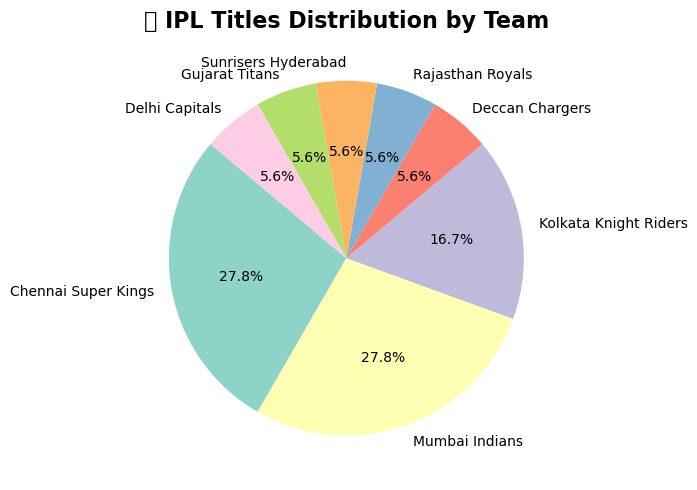

In [21]:
# Count how many times each team won IPL
team_win_count = year_winners['IPL Winner'].value_counts().reset_index()
team_win_count.columns = ['Team', 'Titles']

# Plot pie chart
plt.figure(figsize=(7, 5))
plt.pie(team_win_count['Titles'], 
        labels=team_win_count['Team'],
        autopct='%1.1f%%',
        startangle=140,
        colors=plt.cm.Set3.colors)

plt.title('🏆 IPL Titles Distribution by Team', 
          fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [22]:
# See only columns WITH missing values
missing = ipl.isnull().sum()
print(missing[missing > 0])

extra_type           268185
wicket_kind          269572
player_out           269572
fielders             273433
runs_target          147168
review_batter        282771
team_reviewed        282771
review_decision      282771
umpire               282771
win_outcome            4724
superover_winner     279782
result_type          278954
method               279788
new_batter           270085
power_surge_start    283678
next_batter          270085
dtype: int64


In [23]:
# 1. Drop unnamed column
ipl = ipl.drop(columns=['Unnamed: 0'])

# 2. Fix date format
ipl['date'] = pd.to_datetime(ipl['date'])

# 3. Drop duplicates
ipl = ipl.drop_duplicates()

# 4. Fill run columns with 0
ipl['runs_batter'] = ipl['runs_batter'].fillna(0)
ipl['runs_extras'] = ipl['runs_extras'].fillna(0)
ipl['runs_total'] = ipl['runs_total'].fillna(0)

# 5. Confirm
print("Cleaning Done!")
print("Shape:", ipl.shape)


Cleaning Done!
Shape: (283678, 64)


In [24]:
# Get last ball of each match
last_ball = ipl.groupby(['year', 'match_id']).last().reset_index()

# Get final match of each year
finals = last_ball.groupby('year').last().reset_index()

# Year vs Winner
year_winners = finals[['year', 'match_won_by']]
year_winners.columns = ['Year', 'IPL Winner']
print(year_winners)

    Year             IPL Winner
0   2008       Rajasthan Royals
1   2009        Deccan Chargers
2   2010    Chennai Super Kings
3   2011    Chennai Super Kings
4   2012  Kolkata Knight Riders
5   2013         Mumbai Indians
6   2014  Kolkata Knight Riders
7   2015         Mumbai Indians
8   2016    Sunrisers Hyderabad
9   2017         Mumbai Indians
10  2018    Chennai Super Kings
11  2019         Mumbai Indians
12  2020         Mumbai Indians
13  2021    Chennai Super Kings
14  2022         Gujarat Titans
15  2023    Chennai Super Kings
16  2024  Kolkata Knight Riders
17  2025         Delhi Capitals
18  2026           Punjab Kings


In [25]:
# Check what 'stage' column has
print(ipl['stage'].unique())

['Unknown' 'Semi Final' 'Final' '3rd Place Play-Off' 'Qualifier 1'
 'Elimination Final' 'Qualifier 2' 'Eliminator']


In [26]:
# Filter only final matches
finals_only = ipl[ipl['stage'] == 'Final']

# Get last ball of each final
last_ball_finals = finals_only.groupby(['year', 'match_id']).last().reset_index()

# Get winner each year
year_winners = last_ball_finals[['year', 'match_won_by']].drop_duplicates()
year_winners.columns = ['Year', 'IPL Winner']
print(year_winners)

    Year                   IPL Winner
0   2008             Rajasthan Royals
1   2009              Deccan Chargers
2   2010          Chennai Super Kings
3   2011          Chennai Super Kings
4   2012        Kolkata Knight Riders
5   2013               Mumbai Indians
6   2014        Kolkata Knight Riders
7   2015               Mumbai Indians
8   2016          Sunrisers Hyderabad
9   2017               Mumbai Indians
10  2018          Chennai Super Kings
11  2019               Mumbai Indians
12  2020               Mumbai Indians
13  2021          Chennai Super Kings
14  2022               Gujarat Titans
15  2023          Chennai Super Kings
16  2024        Kolkata Knight Riders
17  2025  Royal Challengers Bengaluru


C:\Users\humer\AppData\Local\Temp\ipykernel_24616\1849520825.py:12: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


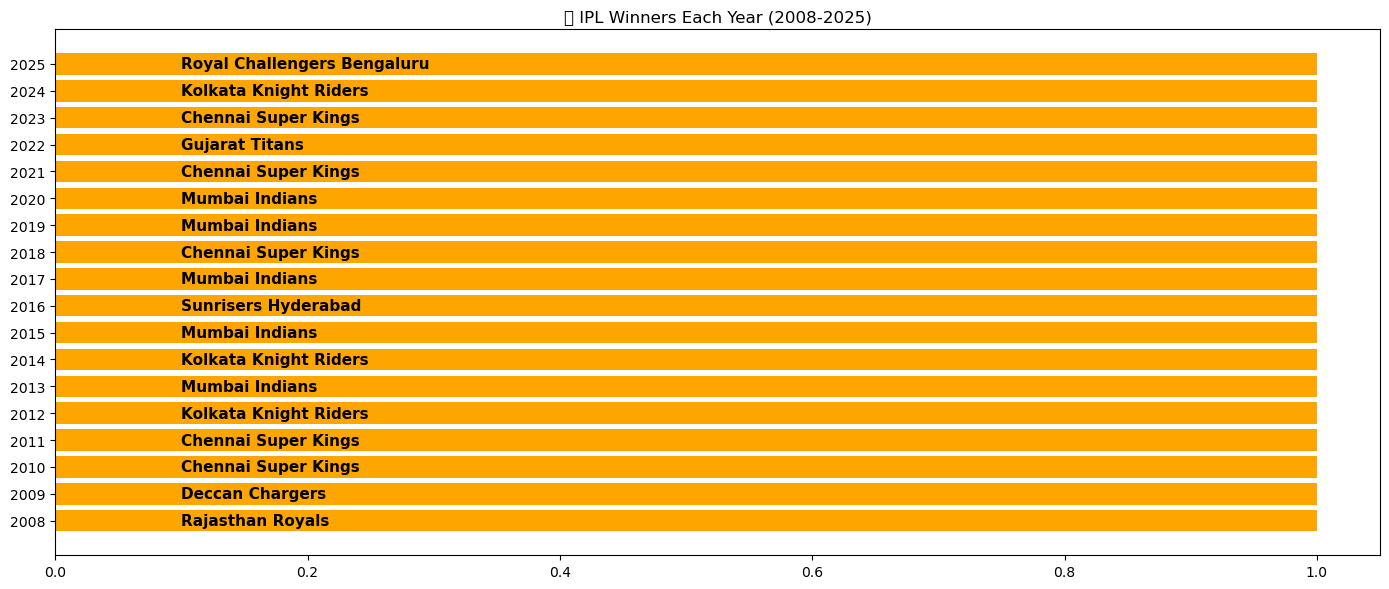

In [27]:
plt.figure(figsize=(14, 6))
plt.barh(year_winners['Year'].astype(str), 
         [1]*len(year_winners),
         color='orange')

for i, (year, winner) in enumerate(zip(year_winners['Year'], 
                                        year_winners['IPL Winner'])):
    plt.text(0.1, i, str(winner), va='center', fontsize=11, fontweight='bold')

plt.xlabel('')
plt.title('🏆 IPL Winners Each Year (2008-2025)')
plt.tight_layout()
plt.show()

C:\Users\humer\AppData\Local\Temp\ipykernel_24616\1025800688.py:38: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


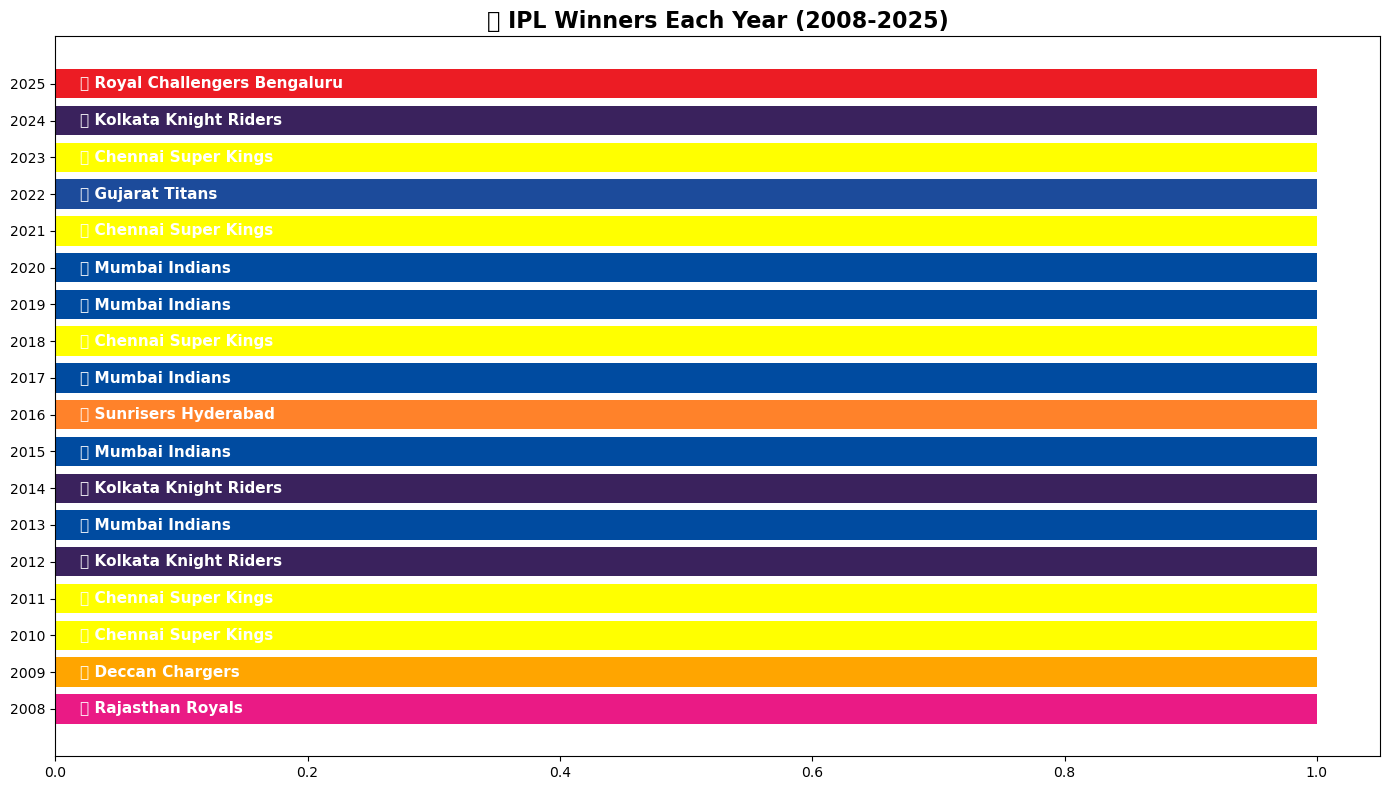

In [28]:
# Team colors dictionary
team_colors = {
    'Mumbai Indians': '#004BA0',
    'Chennai Super Kings': '#FFFF00',
    'Kolkata Knight Riders': '#3A225D',
    'Royal Challengers Bangalore': '#EC1C24',
    'Royal Challengers Bengaluru': '#EC1C24',
    'Sunrisers Hyderabad': '#FF822A',
    'Delhi Capitals': '#0078BC',
    'Delhi Daredevils': '#0078BC',
    'Rajasthan Royals': '#EA1A85',
    'Gujarat Titans': '#1C4B9B',
    'Lucknow Super Giants': '#A0DEFF',
    'Punjab Kings': '#ED1B24',
    'Kings XI Punjab': '#ED1B24',
    'Deccan Chargers': '#FFA500',
}

# Plot with team colors
colors = [team_colors.get(team, '#333333') 
          for team in year_winners['IPL Winner']]

plt.figure(figsize=(14, 8))
bars = plt.barh(year_winners['Year'].astype(str), 
                [1]*len(year_winners),
                color=colors)

# Add team names on bars
for i, (year, winner) in enumerate(zip(year_winners['Year'], 
                                        year_winners['IPL Winner'])):
    plt.text(0.02, i, f"🏆 {winner}", 
             va='center', fontsize=11, 
             fontweight='bold', color='white')

plt.xlabel('')
plt.title('🏆 IPL Winners Each Year (2008-2025)', 
          fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

C:\Users\humer\AppData\Local\Temp\ipykernel_24616\1258775426.py:58: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


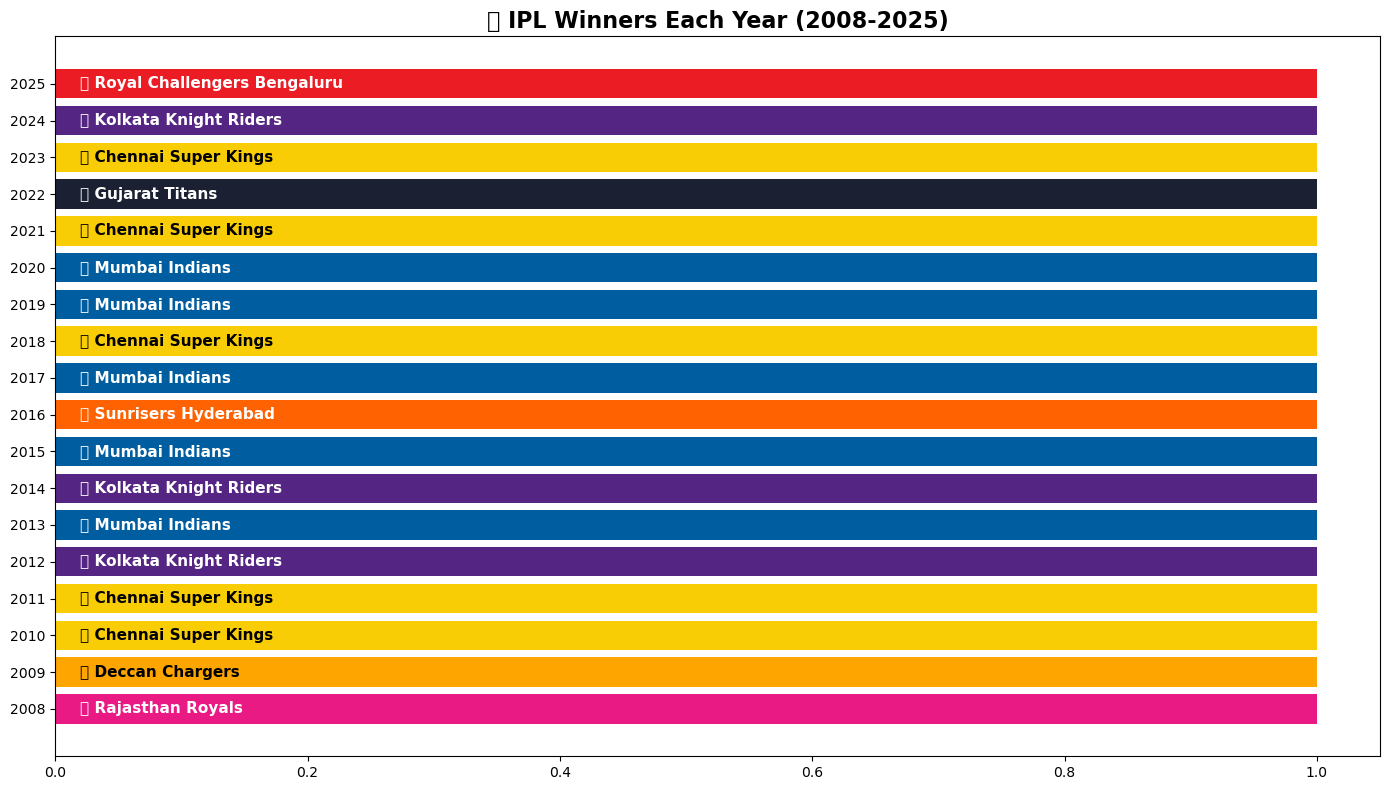

In [29]:
team_colors = {
    'Mumbai Indians':              '#005DA0',  # Deep Blue
    'Chennai Super Kings':         '#F9CD05',  # Bright Yellow
    'Kolkata Knight Riders':       '#552583',  # Purple (different from MI!)
    'Royal Challengers Bangalore': '#EC1C24',  # Red
    'Royal Challengers Bengaluru': '#EC1C24',  # Red
    'Sunrisers Hyderabad':         '#FF6200',  # Orange
    'Delhi Capitals':              '#00AAE7',  # Light Blue
    'Delhi Daredevils':            '#00AAE7',  # Light Blue
    'Rajasthan Royals':            '#EA1A85',  # Pink
    'Gujarat Titans':              '#1B2133',  # Dark Navy
    'Lucknow Super Giants':        '#00B4D8',  # Cyan
    'Punjab Kings':                '#ED1B24',  # Red
    'Kings XI Punjab':             '#ED1B24',  # Red
    'Deccan Chargers':             '#FFA500',  # Orange
}

# Text color (dark teams need white text, light teams need black)
text_colors = {
    'Mumbai Indians':              'white',
    'Chennai Super Kings':         'black',  # yellow bg needs black text
    'Kolkata Knight Riders':       'white',
    'Royal Challengers Bangalore': 'white',
    'Royal Challengers Bengaluru': 'white',
    'Sunrisers Hyderabad':         'white',
    'Delhi Capitals':              'white',
    'Delhi Daredevils':            'white',
    'Rajasthan Royals':            'white',
    'Gujarat Titans':              'white',
    'Lucknow Super Giants':        'black',
    'Punjab Kings':                'white',
    'Kings XI Punjab':             'white',
    'Deccan Chargers':             'black',
}

# Plot
colors = [team_colors.get(team, '#333333') 
          for team in year_winners['IPL Winner']]

txt_colors = [text_colors.get(team, 'white') 
              for team in year_winners['IPL Winner']]

plt.figure(figsize=(14, 8))
bars = plt.barh(year_winners['Year'].astype(str), 
                [1]*len(year_winners),
                color=colors)

for i, (year, winner) in enumerate(zip(year_winners['Year'], 
                                        year_winners['IPL Winner'])):
    plt.text(0.02, i, f"🏆 {winner}", 
             va='center', fontsize=11, 
             fontweight='bold', 
             color=txt_colors[i])

plt.xlabel('')
plt.title('🏆 IPL Winners Each Year (2008-2025)', 
          fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [30]:
# Get finals only - player of match in final = best player
finals_only = ipl[ipl['stage'] == 'Final']

# Get last ball of each final (has player_of_match)
best_player = finals_only.groupby(['year']).last().reset_index()

# Show year, best player, team
best_player_df = best_player[['year', 'player_of_match', 'match_won_by']]
best_player_df.columns = ['Year', 'Player of Match', 'Team']
print(best_player_df)

    Year Player of Match                         Team
0   2008       YK Pathan             Rajasthan Royals
1   2009        A Kumble              Deccan Chargers
2   2010        SK Raina          Chennai Super Kings
3   2011         M Vijay          Chennai Super Kings
4   2012        MS Bisla        Kolkata Knight Riders
5   2013      KA Pollard               Mumbai Indians
6   2014       MK Pandey        Kolkata Knight Riders
7   2015       RG Sharma               Mumbai Indians
8   2016     BCJ Cutting          Sunrisers Hyderabad
9   2017       KH Pandya               Mumbai Indians
10  2018       SR Watson          Chennai Super Kings
11  2019       JJ Bumrah               Mumbai Indians
12  2020        TA Boult               Mumbai Indians
13  2021    F du Plessis          Chennai Super Kings
14  2022       HH Pandya               Gujarat Titans
15  2023       DP Conway          Chennai Super Kings
16  2024        MA Starc        Kolkata Knight Riders
17  2025       KH Pandya  Ro

C:\Users\humer\AppData\Local\Temp\ipykernel_24616\758541653.py:19: UserWarning: Glyph 127941 (\N{SPORTS MEDAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127941 (\N{SPORTS MEDAL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


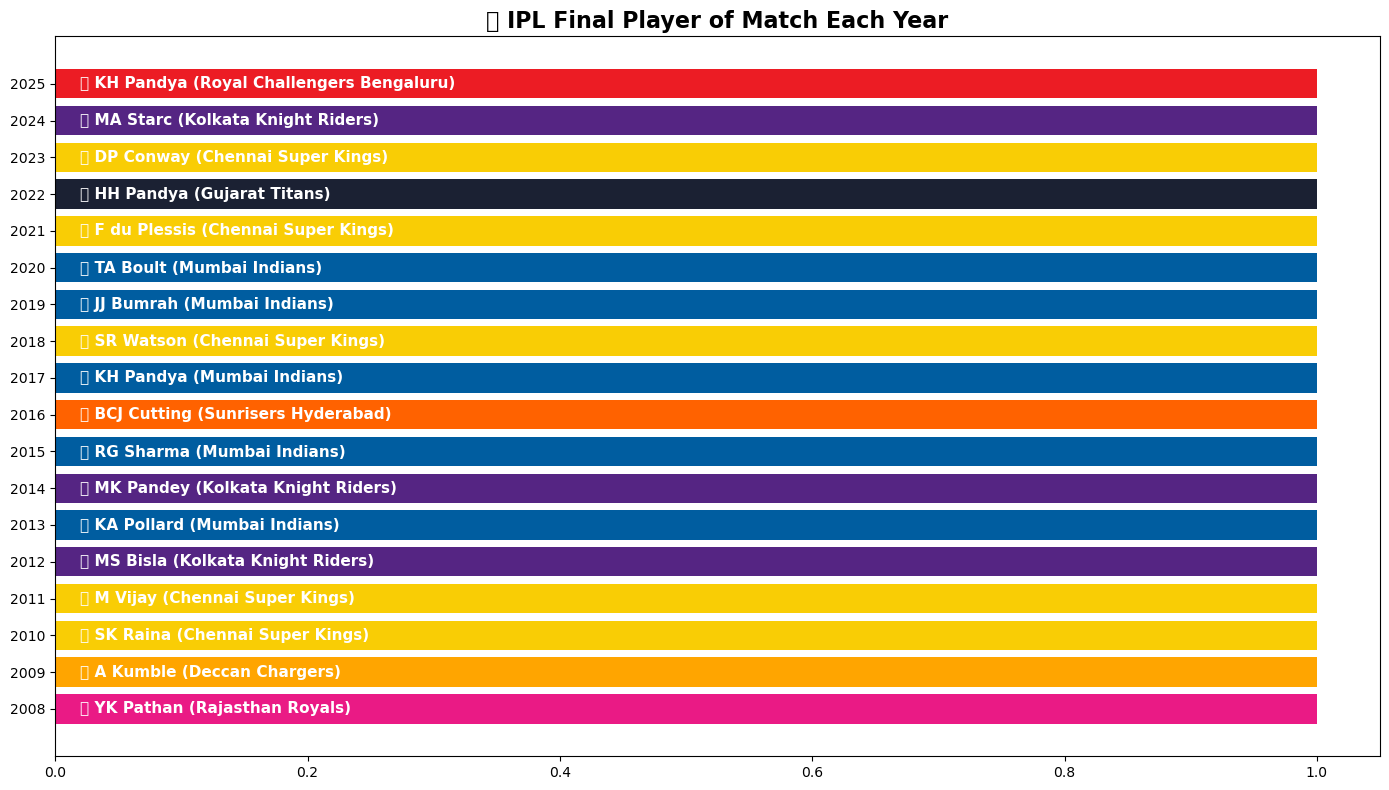

In [31]:
colors = [team_colors.get(team, '#333333') 
          for team in best_player_df['Team']]

plt.figure(figsize=(14, 8))
plt.barh(best_player_df['Year'].astype(str),
         [1]*len(best_player_df),
         color=colors)

for i, (year, player, team) in enumerate(zip(
        best_player_df['Year'],
        best_player_df['Player of Match'],
        best_player_df['Team'])):
    plt.text(0.02, i, f"🏅 {player} ({team})",
             va='center', fontsize=11,
             fontweight='bold', color='white')

plt.title('🏅 IPL Final Player of Match Each Year',
          fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

C:\Users\humer\AppData\Local\Temp\ipykernel_24616\2699667645.py:38: UserWarning: Glyph 127941 (\N{SPORTS MEDAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


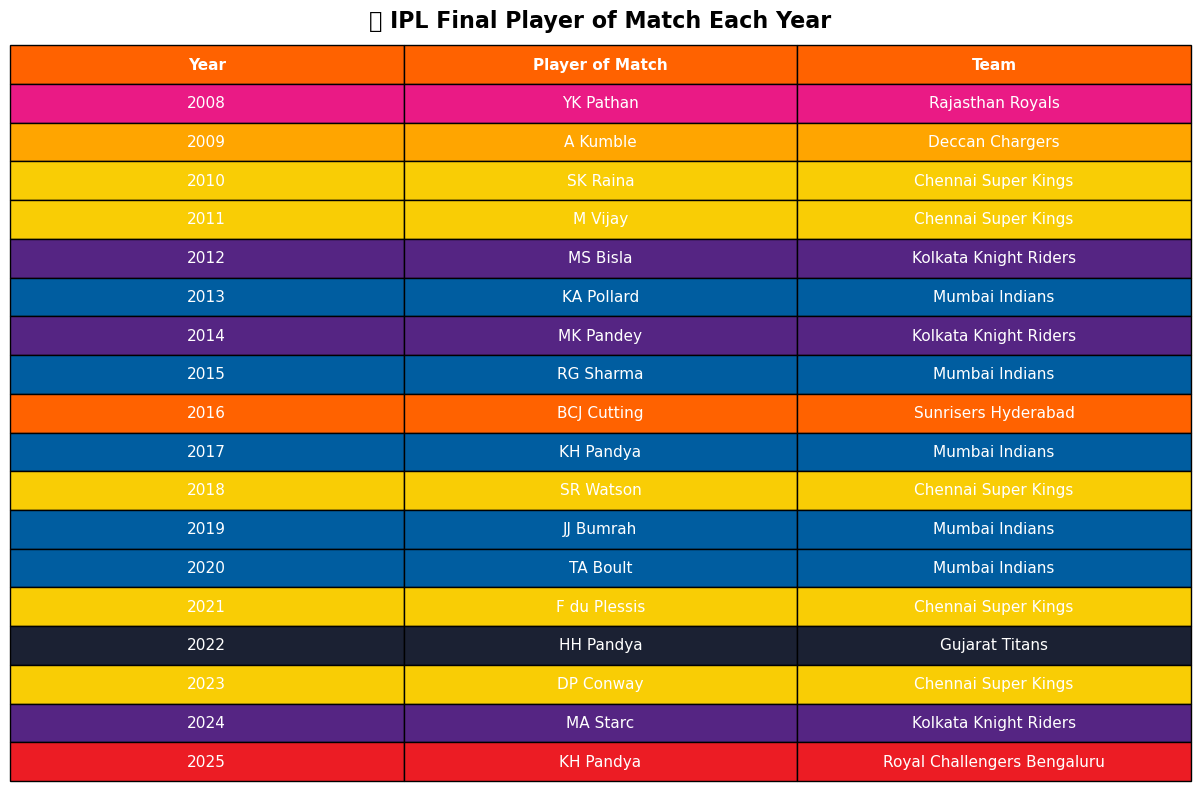

In [32]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 8))
ax.axis('off')

table_data = list(zip(
    best_player_df['Year'],
    best_player_df['Player of Match'],
    best_player_df['Team']
))

table = ax.table(
    cellText=table_data,
    colLabels=['Year', 'Player of Match', 'Team'],
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 2)

# Color header
for j in range(3):
    table[0,j].set_facecolor('#FF6200')
    table[0,j].set_text_props(color='white', 
                               fontweight='bold')

# Color rows with team colors
for i, team in enumerate(best_player_df['Team'], 1):
    color = team_colors.get(team, '#333333')
    for j in range(3):
        table[i,j].set_facecolor(color)
        table[i,j].set_text_props(color='white')

plt.title('🏅 IPL Final Player of Match Each Year',
          fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [33]:
# Total runs by each batsman each year
best_batsman = (ipl.groupby(['year', 'batter'])['runs_batter']
                .sum()
                .reset_index())

# Get top batsman each year
best_batsman = (best_batsman.groupby('year')
                .apply(lambda x: x.nlargest(1, 'runs_batter'))
                .reset_index(drop=True))

best_batsman.columns = ['Year', 'Batsman', 'Total Runs']
print(best_batsman)

    Year          Batsman  Total Runs
0   2008         SE Marsh         616
1   2009        ML Hayden         572
2   2010     SR Tendulkar         618
3   2011         CH Gayle         608
4   2012         CH Gayle         733
5   2013       MEK Hussey         733
6   2014       RV Uthappa         660
7   2015        DA Warner         562
8   2016          V Kohli         973
9   2017        DA Warner         641
10  2018    KS Williamson         735
11  2019        DA Warner         692
12  2020         KL Rahul         676
13  2021       RD Gaikwad         635
14  2022       JC Buttler         863
15  2023     Shubman Gill         890
16  2024          V Kohli         741
17  2025  B Sai Sudharsan         759
18  2026          V Kohli         228


C:\Users\humer\AppData\Local\Temp\ipykernel_24616\1199479769.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(1, 'runs_batter'))


In [34]:
# Filter out 2026
ipl_clean = ipl[ipl['year'] <= 2025]

# Now run best batsman again
best_batsman = (ipl_clean.groupby(['year', 'batter'])['runs_batter']
                .sum()
                .reset_index())

best_batsman = (best_batsman.groupby('year')
                .apply(lambda x: x.nlargest(1, 'runs_batter'))
                .reset_index(drop=True))

best_batsman.columns = ['Year', 'Batsman', 'Total Runs']
print(best_batsman)

    Year          Batsman  Total Runs
0   2008         SE Marsh         616
1   2009        ML Hayden         572
2   2010     SR Tendulkar         618
3   2011         CH Gayle         608
4   2012         CH Gayle         733
5   2013       MEK Hussey         733
6   2014       RV Uthappa         660
7   2015        DA Warner         562
8   2016          V Kohli         973
9   2017        DA Warner         641
10  2018    KS Williamson         735
11  2019        DA Warner         692
12  2020         KL Rahul         676
13  2021       RD Gaikwad         635
14  2022       JC Buttler         863
15  2023     Shubman Gill         890
16  2024          V Kohli         741
17  2025  B Sai Sudharsan         759


C:\Users\humer\AppData\Local\Temp\ipykernel_24616\2354311926.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(1, 'runs_batter'))


C:\Users\humer\AppData\Local\Temp\ipykernel_24616\2080603717.py:23: UserWarning: Glyph 127951 (\N{CRICKET BAT AND BALL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127951 (\N{CRICKET BAT AND BALL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


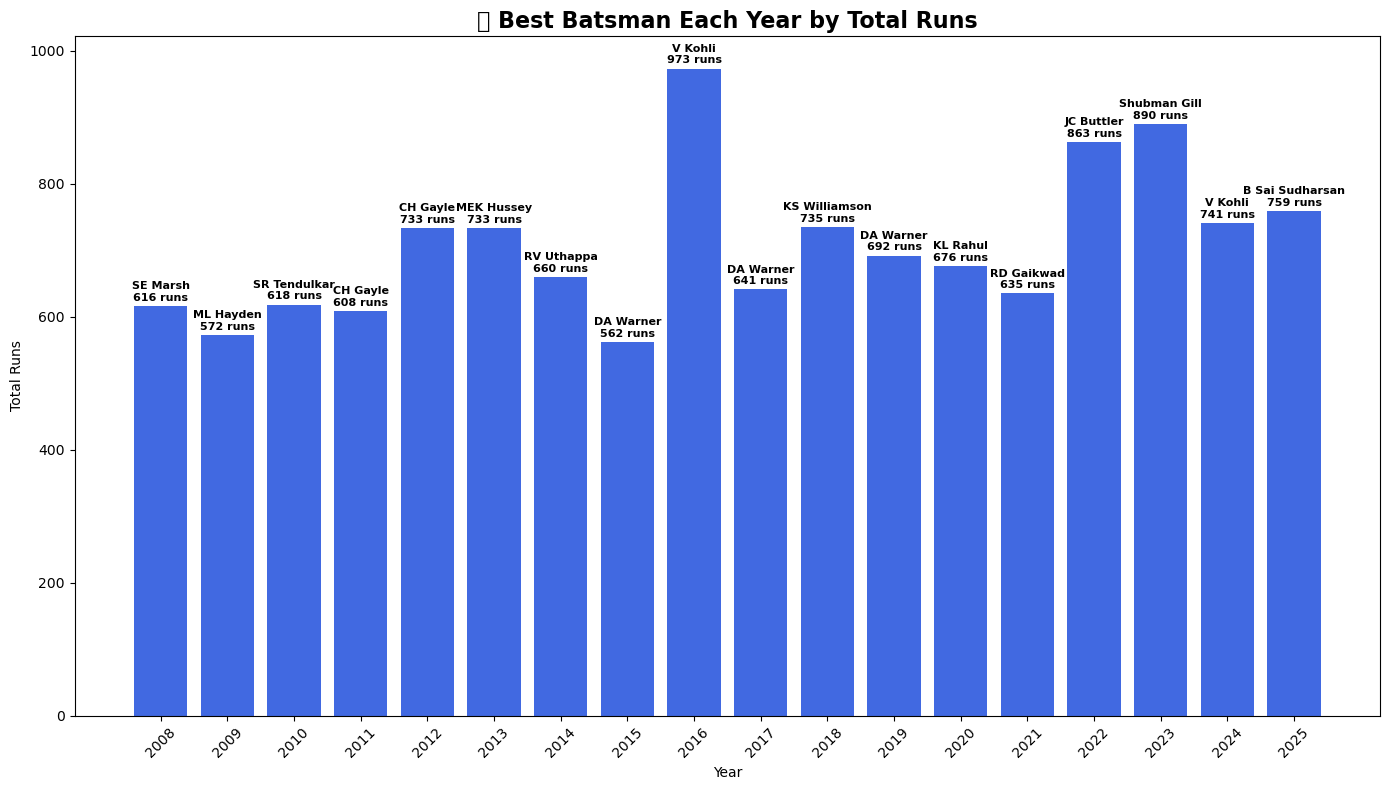

In [35]:
plt.figure(figsize=(14, 8))

bars = plt.bar(best_batsman['Year'].astype(str),
               best_batsman['Total Runs'],
               color='royalblue')

# Add batsman name on each bar
for i, (bar, name, runs) in enumerate(zip(
        bars,
        best_batsman['Batsman'],
        best_batsman['Total Runs'])):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 5,
             f"{name}\n{runs} runs",
             ha='center', va='bottom',
             fontsize=8, fontweight='bold')

plt.xlabel('Year')
plt.ylabel('Total Runs')
plt.title('🏏 Best Batsman Each Year by Total Runs',
          fontsize=16, fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [36]:
# Step 1 - Get best bowler data
wickets = ipl[ipl['wicket_kind'].notna()]
wickets = wickets[wickets['wicket_kind'] != 'run out']

best_bowler = (wickets.groupby(['year', 'bowler'])['wicket_kind']
               .count()
               .reset_index())

best_bowler = (best_bowler.groupby('year')
               .apply(lambda x: x.nlargest(1, 'wicket_kind'))
               .reset_index(drop=True))

best_bowler.columns = ['Year', 'Bowler', 'Total Wickets']

# Step 2 - Remove 2026
best_bowler = best_bowler[best_bowler['Year'] <= 2025]

print(best_bowler)

    Year             Bowler  Total Wickets
0   2008      Sohail Tanvir             22
1   2009           RP Singh             23
2   2010            PP Ojha             21
3   2011         SL Malinga             28
4   2012           M Morkel             25
5   2013           DJ Bravo             32
6   2014          MM Sharma             23
7   2015           DJ Bravo             26
8   2016            B Kumar             23
9   2017            B Kumar             26
10  2018             AJ Tye             24
11  2019        Imran Tahir             26
12  2020           K Rabada             32
13  2021           HV Patel             32
14  2022          YS Chahal             27
15  2023     Mohammed Shami             28
16  2024           HV Patel             24
17  2025  M Prasidh Krishna             25


C:\Users\humer\AppData\Local\Temp\ipykernel_24616\1507681955.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(1, 'wicket_kind'))


In [37]:
# Step 1 - Get best bowler data
wickets = ipl[ipl['wicket_kind'].notna()]
wickets = wickets[wickets['wicket_kind'] != 'run out']

best_bowler = (wickets.groupby(['year', 'bowler'])['wicket_kind']
               .count()
               .reset_index())

best_bowler = (best_bowler.groupby('year')
               .apply(lambda x: x.nlargest(1, 'wicket_kind'))
               .reset_index(drop=True))

best_bowler.columns = ['Year', 'Bowler', 'Total Wickets']

# Step 2 - Remove 2026
best_bowler = best_bowler[best_bowler['Year'] <= 2025]

print(best_bowler)

    Year             Bowler  Total Wickets
0   2008      Sohail Tanvir             22
1   2009           RP Singh             23
2   2010            PP Ojha             21
3   2011         SL Malinga             28
4   2012           M Morkel             25
5   2013           DJ Bravo             32
6   2014          MM Sharma             23
7   2015           DJ Bravo             26
8   2016            B Kumar             23
9   2017            B Kumar             26
10  2018             AJ Tye             24
11  2019        Imran Tahir             26
12  2020           K Rabada             32
13  2021           HV Patel             32
14  2022          YS Chahal             27
15  2023     Mohammed Shami             28
16  2024           HV Patel             24
17  2025  M Prasidh Krishna             25


C:\Users\humer\AppData\Local\Temp\ipykernel_24616\1507681955.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(1, 'wicket_kind'))


In [39]:
# Top 10 run scorers all time
top_scorers = ipl.groupby('batter')['runs_batter'].sum().reset_index()
top_scorers.columns = ['Batsman', 'Total Runs']
top_scorers = top_scorers.sort_values('Total Runs', ascending=False).head(10)
print(top_scorers)

            Batsman  Total Runs
674         V Kohli        8899
514       RG Sharma        7185
550        S Dhawan        6769
155       DA Warner        6567
584        SK Raina        5536
400        MS Dhoni        5439
304        KL Rahul        5346
51        AM Rahane        5184
31   AB de Villiers        5181
131        CH Gayle        4997


C:\Users\humer\AppData\Local\Temp\ipykernel_24616\3190941033.py:23: UserWarning: Glyph 127951 (\N{CRICKET BAT AND BALL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127951 (\N{CRICKET BAT AND BALL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


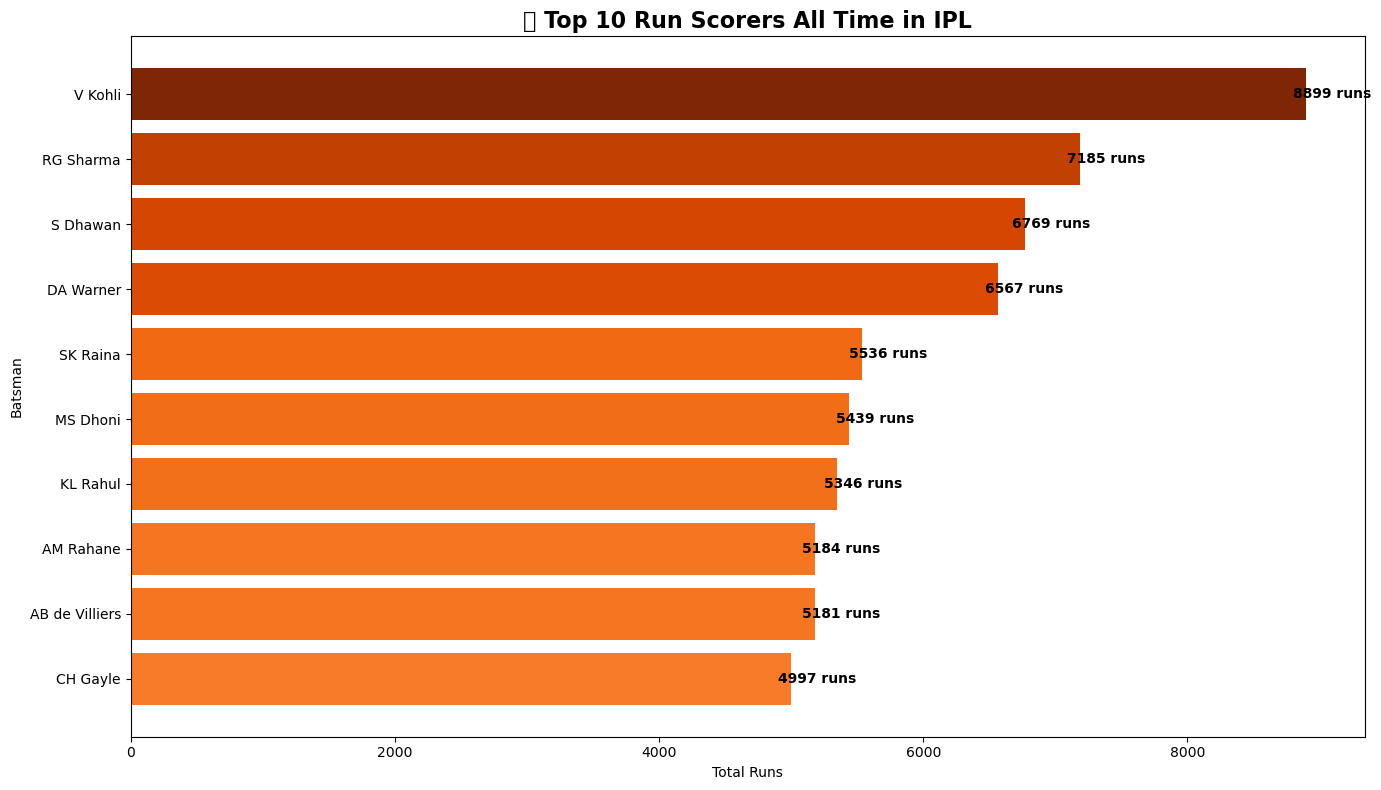

In [40]:
plt.figure(figsize=(14, 8))

colors = plt.cm.Oranges([r/top_scorers['Total Runs'].max() 
                          for r in top_scorers['Total Runs']])

bars = plt.barh(top_scorers['Batsman'],
                top_scorers['Total Runs'],
                color=colors)

# Add run count on each bar
for bar, runs in zip(bars, top_scorers['Total Runs']):
    plt.text(bar.get_width() - 100,
             bar.get_y() + bar.get_height()/2,
             f"{runs} runs",
             va='center', fontsize=10,
             fontweight='bold', color='black')

plt.xlabel('Total Runs')
plt.ylabel('Batsman')
plt.title('🏏 Top 10 Run Scorers All Time in IPL',
          fontsize=16, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [41]:
# Check if toss winner = match winner
ipl_matches = ipl.groupby('match_id').last().reset_index()

# Did toss winner win the match?
ipl_matches['toss_won_match'] = (ipl_matches['toss_winner'] == 
                                  ipl_matches['match_won_by'])

# Count yes/no
toss_impact = ipl_matches['toss_won_match'].value_counts()
print(toss_impact)

# Percentage
total = len(ipl_matches)
won = ipl_matches['toss_won_match'].sum()
lost = total - won

print(f"\nToss winner won match: {won} times ({won/total*100:.1f}%)")
print(f"Toss winner lost match: {lost} times ({lost/total*100:.1f}%)")

toss_won_match
True     606
False    587
Name: count, dtype: int64

Toss winner won match: 606 times (50.8%)
Toss winner lost match: 587 times (49.2%)


C:\Users\humer\AppData\Local\Temp\ipykernel_24616\1364231668.py:20: UserWarning: Glyph 127922 (\N{GAME DIE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127922 (\N{GAME DIE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


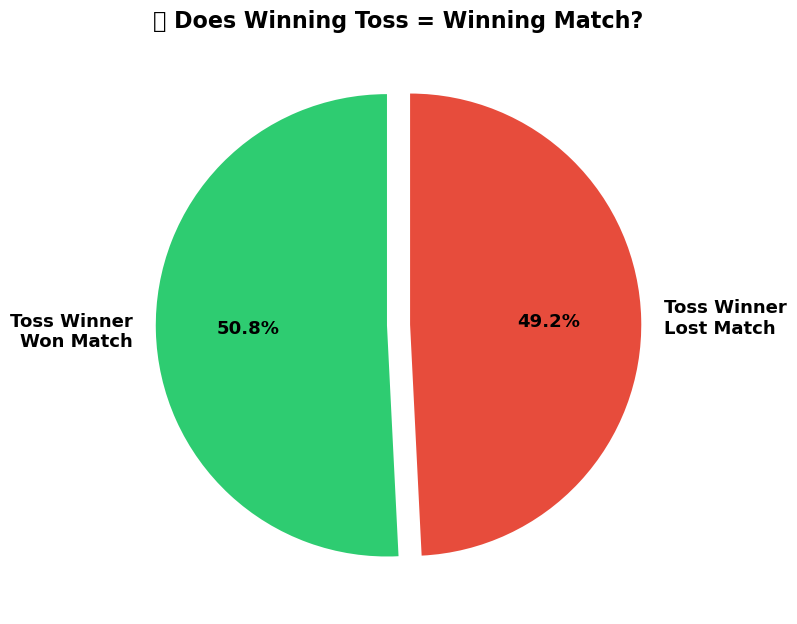

In [42]:
plt.figure(figsize=(8, 8))

labels = ['Toss Winner\nWon Match', 
          'Toss Winner\nLost Match']
sizes = [won, lost]
colors = ['#2ecc71', '#e74c3c']
explode = (0.05, 0.05)

plt.pie(sizes, 
        labels=labels,
        colors=colors,
        explode=explode,
        autopct='%1.1f%%',
        startangle=90,
        textprops={'fontsize': 13,
                   'fontweight': 'bold'})

plt.title('🎲 Does Winning Toss = Winning Match?',
          fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [43]:
# Wins per team per year
year_wise_wins = (ipl.groupby('match_id')
                  .last()
                  .reset_index()
                  .groupby(['year', 'match_won_by'])
                  .size()
                  .reset_index(name='Wins'))

# Remove Unknown
year_wise_wins = year_wise_wins[
    year_wise_wins['match_won_by'] != 'Unknown']

print(year_wise_wins.head(20))

    year                 match_won_by  Wins
0   2008          Chennai Super Kings     9
1   2008              Deccan Chargers     2
2   2008             Delhi Daredevils     7
3   2008              Kings XI Punjab    10
4   2008        Kolkata Knight Riders     6
5   2008               Mumbai Indians     7
6   2008             Rajasthan Royals    13
7   2008  Royal Challengers Bangalore     4
8   2009          Chennai Super Kings     8
9   2009              Deccan Chargers     9
10  2009             Delhi Daredevils    10
11  2009              Kings XI Punjab     7
12  2009        Kolkata Knight Riders     3
13  2009               Mumbai Indians     5
14  2009             Rajasthan Royals     5
15  2009  Royal Challengers Bangalore     9
17  2010          Chennai Super Kings     9
18  2010              Deccan Chargers     8
19  2010             Delhi Daredevils     7
20  2010              Kings XI Punjab     3


In [45]:
# Total wins by each team
team_wins = ipl.groupby('match_won_by')['match_id'].nunique().reset_index()
team_wins.columns = ['match_won_by', 'Total Wins']
team_wins = team_wins.sort_values('Total Wins', ascending=False).head(10)
print(team_wins)

                   match_won_by  Total Wins
10               Mumbai Indians         152
0           Chennai Super Kings         144
8         Kolkata Knight Riders         135
13             Rajasthan Royals         118
16  Royal Challengers Bangalore         114
18          Sunrisers Hyderabad          95
6               Kings XI Punjab          85
3              Delhi Daredevils          67
2                Delhi Capitals          53
5                Gujarat Titans          39


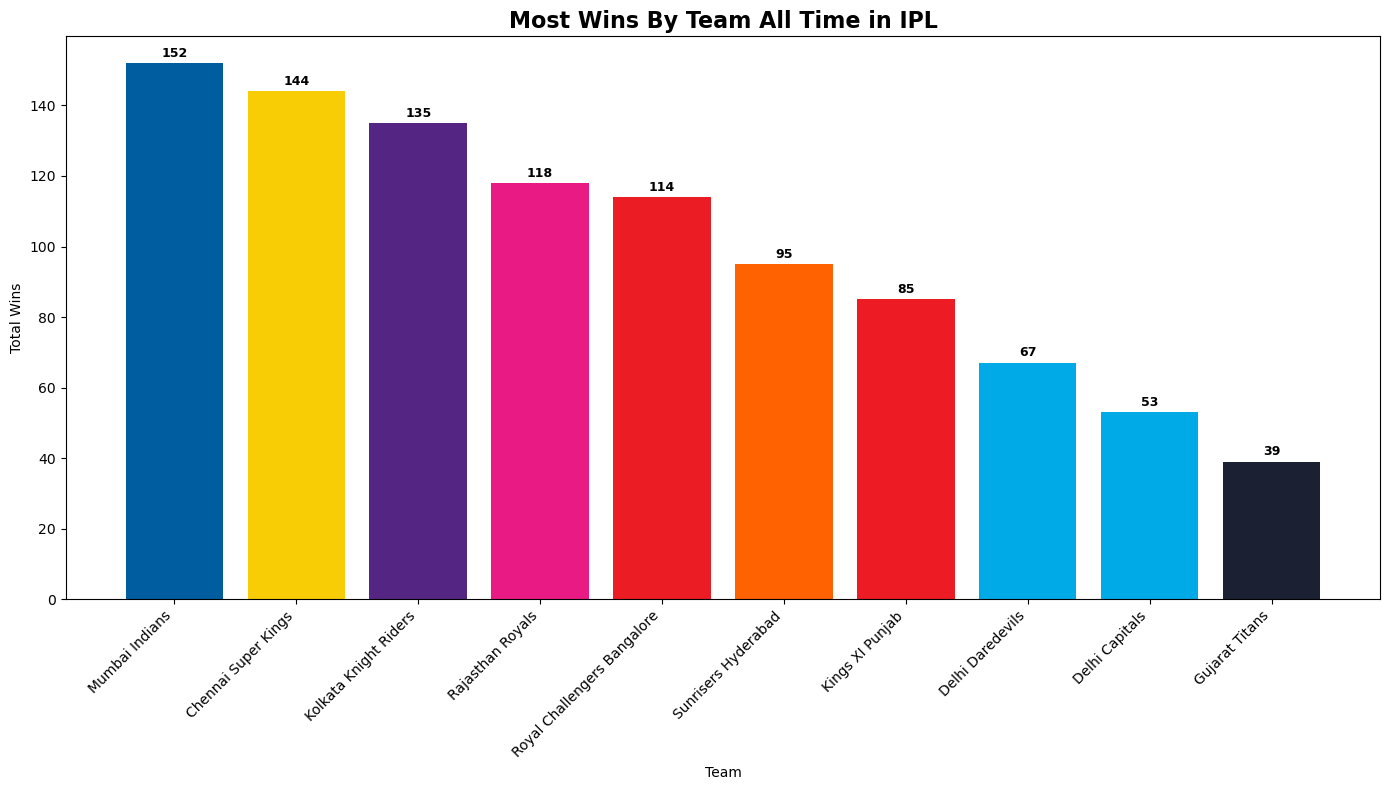

In [46]:
plt.figure(figsize=(14, 8))

colors = [team_colors.get(team, '#333333') 
          for team in team_wins['match_won_by']]

bars = plt.bar(team_wins['match_won_by'],
               team_wins['Total Wins'],
               color=colors)

# Add win count on top
for bar, wins in zip(bars, team_wins['Total Wins']):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1,
             str(wins),
             ha='center', va='bottom',
             fontsize=9, fontweight='bold')

plt.xlabel('Team')
plt.ylabel('Total Wins')
plt.title('Most Wins By Team All Time in IPL',
          fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [47]:
# Filter for both players
players = ['V Kohli', 'RG Sharma']

career_stats = []

for player in players:
    player_data = ipl[ipl['batter'] == player]
    
    stats = {
        'Player': player,
        'Total Runs': player_data['runs_batter'].sum(),
        'Total Balls': player_data['balls_faced'].sum(),
        'Matches': player_data['match_id'].nunique(),
        'Fours': len(player_data[player_data['runs_batter'] == 4]),
        'Sixes': len(player_data[player_data['runs_batter'] == 6]),
        'Highest Score': player_data.groupby('match_id')['runs_batter'].sum().max(),
        'Average': round(player_data['runs_batter'].sum() / 
                        player_data['match_id'].nunique(), 2),
        'Strike Rate': round((player_data['runs_batter'].sum() / 
                             player_data['balls_faced'].sum()) * 100, 2),
    }
    career_stats.append(stats)

career_df = pd.DataFrame(career_stats)
print(career_df)

      Player  Total Runs  Total Balls  Matches  Fours  Sixes  Highest Score  \
0    V Kohli        8899         6667      264    799    300            113   
1  RG Sharma        7185         5420      270    653    311            109   

   Average  Strike Rate  
0    33.71       133.48  
1    26.61       132.56  


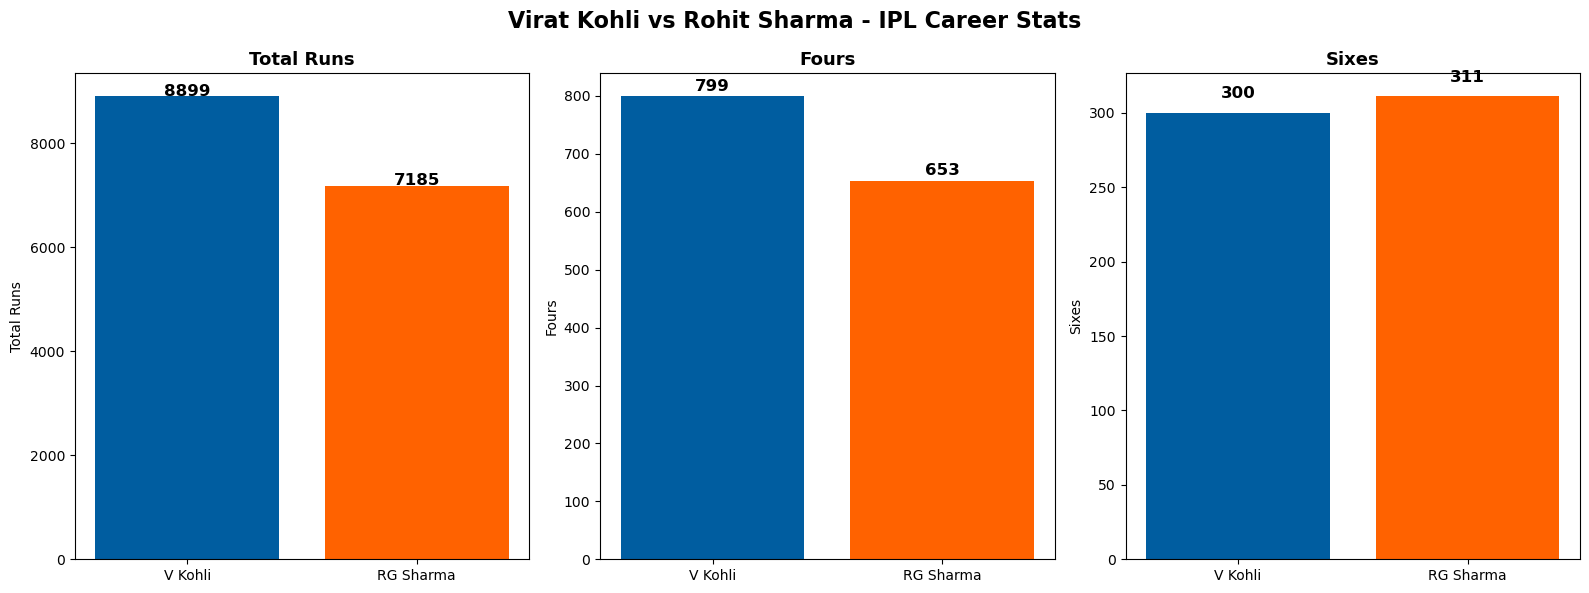

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

metrics = ['Total Runs', 'Fours', 'Sixes']
colors_players = ['#005DA0', '#004BA0']  # Blue shades

for i, metric in enumerate(metrics):
    axes[i].bar(career_df['Player'],
                career_df[metric],
                color=['#005DA0', '#FF6200'])
    
    # Add values on bars
    for bar, val in zip(axes[i].patches, career_df[metric]):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 10,
                    str(val),
                    ha='center', fontsize=12,
                    fontweight='bold')
    
    axes[i].set_title(metric, fontsize=13, fontweight='bold')
    axes[i].set_ylabel(metric)

plt.suptitle('Virat Kohli vs Rohit Sharma - IPL Career Stats',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 📊 SQL Analysis
#Running SQL queries on IPL data using SQLite

In [49]:


import sqlite3
import pandas as pd

conn = sqlite3.connect(':memory:')
ipl.to_sql('ipl', conn, index=False)

# 🏏 Top 10 Run Scorers
query1 = """
SELECT batter, SUM(runs_batter) AS total_runs
FROM ipl
GROUP BY batter
ORDER BY total_runs DESC
LIMIT 10
"""
pd.read_sql(query1, conn)



,batter,total_runs
0,V Kohli,8899
1,RG Sharma,7185
2,S Dhawan,6769
3,DA Warner,6567
4,SK Raina,5536
5,MS Dhoni,5439
6,KL Rahul,5346
7,AM Rahane,5184
8,AB de Villiers,5181
9,CH Gayle,4997


In [50]:
# 2. Top 10 Wicket Takers
query2 = """
SELECT bowler, SUM(bowler_wicket) AS total_wickets
FROM ipl
GROUP BY bowler
ORDER BY total_wickets DESC
LIMIT 10
"""
print("🎳 Top 10 Wicket Takers")
print(pd.read_sql(query2, conn))
print()

🎳 Top 10 Wicket Takers
       bowler  total_wickets
0   YS Chahal            224
1     B Kumar            205
2   SP Narine            195
3   PP Chawla            192
4    R Ashwin            187
5   JJ Bumrah            186
6    DJ Bravo            183
7    A Mishra            174
8   RA Jadeja            173
9  SL Malinga            170



In [51]:
# 3. Most Sixes by Team
query3 = """
SELECT batting_team, COUNT(*) AS total_sixes
FROM ipl
WHERE runs_batter = 6
GROUP BY batting_team
ORDER BY total_sixes DESC
LIMIT 10
"""
print("💥 Most Sixes by Each Team")
print(pd.read_sql(query3, conn))
print()

💥 Most Sixes by Each Team
                  batting_team  total_sixes
0               Mumbai Indians         1876
1          Chennai Super Kings         1652
2        Kolkata Knight Riders         1628
3  Royal Challengers Bangalore         1488
4             Rajasthan Royals         1431
5          Sunrisers Hyderabad         1219
6              Kings XI Punjab         1075
7             Delhi Daredevils          801
8               Delhi Capitals          691
9                 Punjab Kings          667



In [52]:
# 4. Toss Winner vs Match Winner
query4 = """
SELECT COUNT(*) AS toss_match_wins
FROM ipl
WHERE toss_winner = match_won_by
"""
print("🪙 Toss Winner = Match Winner Count")
print(pd.read_sql(query4, conn))
print()


🪙 Toss Winner = Match Winner Count
   toss_match_wins
0           143343



In [53]:
# 5. Highest Average Score by Venue
query5 = """
SELECT venue, ROUND(AVG(team_runs), 2) AS avg_runs
FROM ipl
GROUP BY venue
ORDER BY avg_runs DESC
LIMIT 10
"""
print("🏟️ Top 10 Venues by Average Score")
print(pd.read_sql(query5, conn))
print()

🏟️ Top 10 Venues by Average Score
                                               venue  avg_runs
0  Maharaja Yadavindra Singh International Cricke...    106.02
1  Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket St...     96.38
2                        Arun Jaitley Stadium, Delhi     93.97
3                              Eden Gardens, Kolkata     92.33
4                   M Chinnaswamy Stadium, Bengaluru     90.65
5  Punjab Cricket Association IS Bindra Stadium, ...     90.37
6  Himachal Pradesh Cricket Association Stadium, ...     90.32
7  Rajiv Gandhi International Stadium, Uppal, Hyd...     89.80
8                     Sawai Mansingh Stadium, Jaipur     87.11
9                   Narendra Modi Stadium, Ahmedabad     86.67



In [54]:
# 6. Virat Kohli Runs Each Season
query6 = """
SELECT batter, season, SUM(runs_batter) AS total_runs
FROM ipl
WHERE batter = 'V Kohli'
GROUP BY season
ORDER BY season ASC
"""
print("👑 Virat Kohli Runs Each Season")
print(pd.read_sql(query6, conn))
print()

👑 Virat Kohli Runs Each Season
     batter   season  total_runs
0   V Kohli  2007/08         165
1   V Kohli     2009         246
2   V Kohli  2009/10         307
3   V Kohli     2011         557
4   V Kohli     2012         364
5   V Kohli     2013         639
6   V Kohli     2014         359
7   V Kohli     2015         505
8   V Kohli     2016         973
9   V Kohli     2017         308
10  V Kohli     2018         530
11  V Kohli     2019         464
12  V Kohli  2020/21         471
13  V Kohli     2021         405
14  V Kohli     2022         341
15  V Kohli     2023         639
16  V Kohli     2024         741
17  V Kohli     2025         657
18  V Kohli     2026         228



In [55]:
# 7. Toss Wins Per Team
query7 = """
SELECT toss_winner, COUNT(toss_winner) AS toss_wins
FROM ipl
GROUP BY toss_winner
ORDER BY toss_wins DESC
"""
print("🪙 Toss Wins Per Team")
print(pd.read_sql(query7, conn))
print()

🪙 Toss Wins Per Team
                    toss_winner  toss_wins
0                Mumbai Indians      36890
1              Rajasthan Royals      31308
2           Chennai Super Kings      30976
3         Kolkata Knight Riders      30869
4   Royal Challengers Bangalore      26701
5           Sunrisers Hyderabad      22363
6               Kings XI Punjab      20326
7              Delhi Daredevils      18548
8                Delhi Capitals      15021
9               Deccan Chargers      10376
10                 Punjab Kings       9623
11               Gujarat Titans       7309
12         Lucknow Super Giants       6389
13                Pune Warriors       4798
14  Royal Challengers Bengaluru       3961
15                Gujarat Lions       3586
16         Kochi Tuskers Kerala       1760
17      Rising Pune Supergiants       1503
18       Rising Pune Supergiant       1371



In [56]:
# 8. Most Matches Played Per Team
query8 = """
SELECT batting_team, COUNT(DISTINCT match_id) AS matches_played
FROM ipl
GROUP BY batting_team
ORDER BY matches_played DESC
"""
print("📊 Most Matches Played Per Team")
print(pd.read_sql(query8, conn))
print()

📊 Most Matches Played Per Team
                   batting_team  matches_played
0                Mumbai Indians             282
1         Kolkata Knight Riders             269
2           Chennai Super Kings             256
3   Royal Challengers Bangalore             240
4              Rajasthan Royals             239
5           Sunrisers Hyderabad             200
6               Kings XI Punjab             190
7              Delhi Daredevils             161
8                Delhi Capitals             109
9                  Punjab Kings              78
10              Deccan Chargers              75
11               Gujarat Titans              64
12         Lucknow Super Giants              63
13                Pune Warriors              45
14  Royal Challengers Bengaluru              35
15                Gujarat Lions              30
16       Rising Pune Supergiant              16
17      Rising Pune Supergiants              14
18         Kochi Tuskers Kerala              14



## 📝 Key Findings
- V Kohli is highest run scorer
- Mumbai Indians played most matches
- Toss winner wins X% of matches
-  Wankhede Stadium has highest average score